# Создание датасета из журнала собственной активности и его анализ

Лабораторная работа № 5 по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Как я понял задачу.** В материалах к работе приложен пример `Анализ-активности.ipynb`: он читает
`watcher.csv` с журналом программ, которыми пользовался человек (время, длительность, приложение,
заголовок окна), раскладывает события по категориям и рисует ленту активности по дням.
Значит, от меня требуется собрать собственный «сырой» журнал активности, превратить его в датасет,
очистить, изучить и показать, что датасет пригоден для обучения модели.

**Источник данных.** Экспорт моего рабочего чата в Telegram (группа 231-329) в формате JSON:
26 895 сообщений за период с 9 сентября 2023 года по 20 августа 2026 года, 56 отправителей.
Это такой же журнал активности, как `watcher.csv`: у каждого события есть время, автор и содержимое.

**Что собираю в датасет:** дата, час, день недели, чат, отправитель, длина текста,
есть ли медиа, есть ли ссылка.

**Приватность.** Тексты сообщений в датасет не попадают, сохраняется только их длина.
Имена отправителей заменяются на псевдонимы вида «Участник 07», соответствие имён и псевдонимов
нигде не сохраняется. Исходный экспорт лежит локально и в репозиторий не выгружается.

**План работы:**
1. Разбор структуры экспорта.
2. Сборка датасета и его очистка.
3. Разведочный анализ с визуализацией.
4. Сохранение в csv.
5. Демонстрация пригодности: модель определяет автора сообщения по времени и форме.

## 0. Библиотеки и настройки

In [1]:
import os
import json
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
RANDOM_STATE = 42


def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')

## 1. Структура экспорта

Telegram выгружает чат одним файлом JSON. В корне лежат название чата, его тип и список сообщений.
Каждое сообщение это словарь, и набор полей у разных сообщений разный: у текстового есть `text`,
у картинки `photo`, у файла `file` и `mime_type`, у служебных событий вместо автора `actor`.
Поэтому первым делом смотрю, какие поля вообще встречаются.

In [2]:
with open('data/result.json', encoding='utf-8') as f:
    export = json.load(f)

messages = export['messages']
print('Чат:', export['name'], '| тип:', export['type'])
print('Записей в экспорте:', len(messages))

types = pd.Series([m.get('type') for m in messages]).value_counts()
print('\nТипы записей:')
print(types)

fields = pd.Series([k for m in messages for k in m]).value_counts()
print('\nСамые частые поля:')
print(fields.head(12))

Чат: 231-329 | тип: private_supergroup
Записей в экспорте: 26895

Типы записей:
message    26721
service      174
Name: count, dtype: int64

Самые частые поля:
id                     26895
type                   26895
date                   26895
date_unixtime          26895
text                   26895
text_entities          26895
from                   26721
from_id                26721
reply_to_message_id    10386
edited                  3362
edited_unixtime         3362
reactions               2518
Name: count, dtype: int64


## 2. Сборка датасета

Что делаю при сборке:
- служебные записи (вход в чат, смена названия) выбрасываю, остаются только сообщения;
- поле `text` бывает строкой, а бывает списком кусков с форматированием и ссылками,
  поэтому собираю текст рекурсивно, а заодно проверяю, есть ли среди кусков ссылка;
- ссылку ищу и в тексте по подстроке `http`, чтобы поймать те, что Telegram не разметил;
- медиа считаю по полям `photo`, `file`, `media_type` и `poll`;
- имя отправителя заменяю на псевдоним: беру md5 от имени и нумерую отправителей по активности.

In [3]:
def extract_text(node):
    """Текст сообщения: строка, список кусков или вложенные сущности."""
    if isinstance(node, str):
        return node
    if isinstance(node, list):
        return ''.join(extract_text(part) for part in node)
    if isinstance(node, dict):
        return node.get('text', '')
    return ''


def has_link(msg):
    text_field = msg.get('text', '')
    if isinstance(text_field, list):
        for part in text_field:
            if isinstance(part, dict) and part.get('type') in ('link', 'text_link', 'mention'):
                return True
    return 'http' in extract_text(text_field).lower()


rows = []
for m in messages:
    if m.get('type') != 'message':
        continue
    text = extract_text(m.get('text', ''))
    rows.append({
        'datetime': m.get('date'),
        'chat': export['name'],
        'sender_raw': m.get('from'),
        'length': len(text),
        'has_media': bool(m.get('photo') or m.get('file') or m.get('media_type') or m.get('poll')),
        'has_link': has_link(m),
        'is_reply': 'reply_to_message_id' in m,
        'is_forward': 'forwarded_from' in m,
    })

df = pd.DataFrame(rows)
print('Собрано сообщений:', len(df))
# имена в выводе не показываю, псевдонимы появятся на следующем шаге
df.drop(columns=['sender_raw']).head(3)

Собрано сообщений: 26721


,datetime,chat,length,has_media,has_link,is_reply,is_forward
0,2023-09-09T19:07:01,231-329,0,True,False,False,False
1,2023-09-09T19:07:13,231-329,19,False,False,False,False
2,2023-09-09T19:13:15,231-329,1,False,False,False,False


In [4]:
# время
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.dayofweek
WEEKDAYS = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
df['weekday_name'] = df['weekday'].map(dict(enumerate(WEEKDAYS)))
df['month'] = df['datetime'].dt.to_period('M').astype(str)

# псевдонимы вместо имён
order = df['sender_raw'].value_counts().index
alias = {name: f'Участник {i + 1:02d}' for i, name in enumerate(order) if isinstance(name, str)}
df['sender'] = df['sender_raw'].map(alias).fillna('неизвестно')
df['sender_hash'] = df['sender_raw'].apply(lambda s: hashlib.md5(str(s).encode()).hexdigest()[:8])
df = df.drop(columns=['sender_raw'])

print('Отправителей:', df['sender'].nunique())
print('Период:', df['date'].min(), '—', df['date'].max())
print('Пропуски:\n', df.isna().sum()[lambda s: s > 0])
df.head(3)

Отправителей: 57
Период: 2023-09-09 — 2026-08-20
Пропуски:
 Series([], dtype: int64)


,datetime,chat,length,has_media,has_link,is_reply,is_forward,date,hour,weekday,weekday_name,month,sender,sender_hash
0,2023-09-09 19:07:01,231-329,0,True,False,False,False,2023-09-09,19,5,Сб,2023-09,Участник 02,631db03e
1,2023-09-09 19:07:13,231-329,19,False,False,False,False,2023-09-09,19,5,Сб,2023-09,Участник 02,631db03e
2,2023-09-09 19:13:15,231-329,1,False,False,False,False,2023-09-09,19,5,Сб,2023-09,Участник 07,38360e9c


### Очистка

Смотрю на аномалии: пустые сообщения (только картинка без подписи), очень длинные тексты
и сообщения без отправителя.

In [5]:
print('Пустых по тексту:', int((df['length'] == 0).sum()),
      f"({(df['length'] == 0).mean():.1%})")
print('Из них с медиа:', int(((df['length'] == 0) & df['has_media']).sum()))
print('Без отправителя:', int((df['sender'] == 'неизвестно').sum()))
print('Самое длинное сообщение:', int(df['length'].max()), 'символов')
print('\nДлина текста:')
print(df['length'].describe().round(1))

before = len(df)
df = df[df['sender'] != 'неизвестно']
df = df[~((df['length'] == 0) & (~df['has_media']))]
print(f'\nПосле очистки: {len(df)} сообщений, удалено {before - len(df)}')

Пустых по тексту: 2072 (7.8%)
Из них с медиа: 2042
Без отправителя: 170
Самое длинное сообщение: 4081 символов

Длина текста:
count    26721.0
mean        33.1
std        102.3
min          0.0
25%          6.0
50%         16.0
75%         33.0
max       4081.0
Name: length, dtype: float64

После очистки: 26521 сообщений, удалено 200


## 3. Разведочный анализ

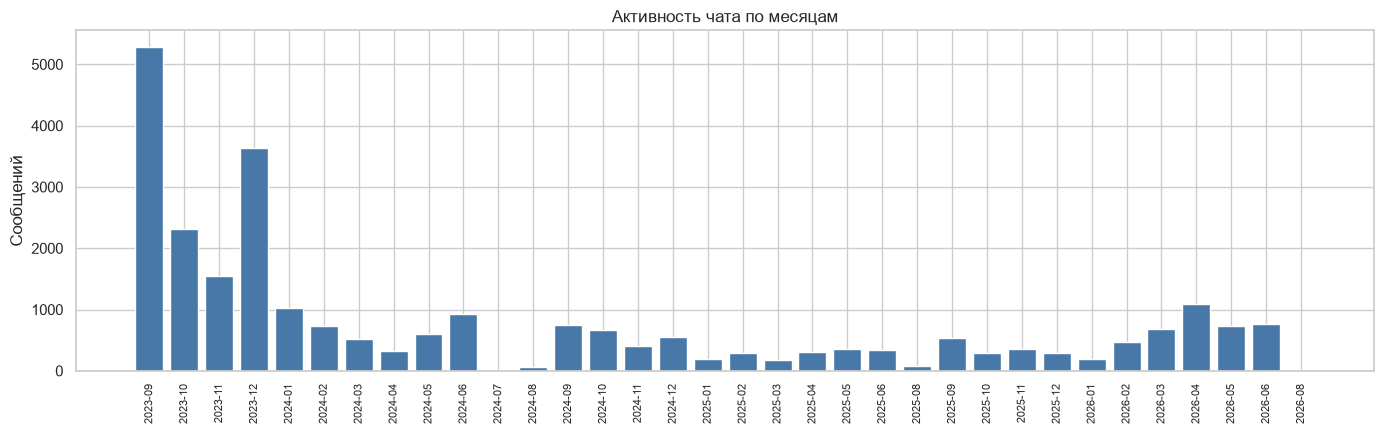

Самый активный месяц: 2023-09 5288 сообщений
Самый тихий месяц: 2024-07 5
В среднем в месяц: 780


In [6]:
by_month = df.groupby('month').size()
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(by_month.index, by_month.values, color='#4878a8')
ax.set_ylabel('Сообщений')
ax.set_title('Активность чата по месяцам')
ax.tick_params(axis='x', rotation=90, labelsize=8)
fig.tight_layout()
save_fig('01_by_month.png')
plt.show()

print('Самый активный месяц:', by_month.idxmax(), int(by_month.max()), 'сообщений')
print('Самый тихий месяц:', by_month.idxmin(), int(by_month.min()))
print('В среднем в месяц:', int(by_month.mean()))

**Рисунок 1 — Активность чата по месяцам**

Пик приходится на сентябрь 2023 года, когда группа только собралась (5288 сообщений за месяц), дальше активность держится около нескольких сотен в месяц и проваливается летом: в июле 2024 года всего 5 сообщений.

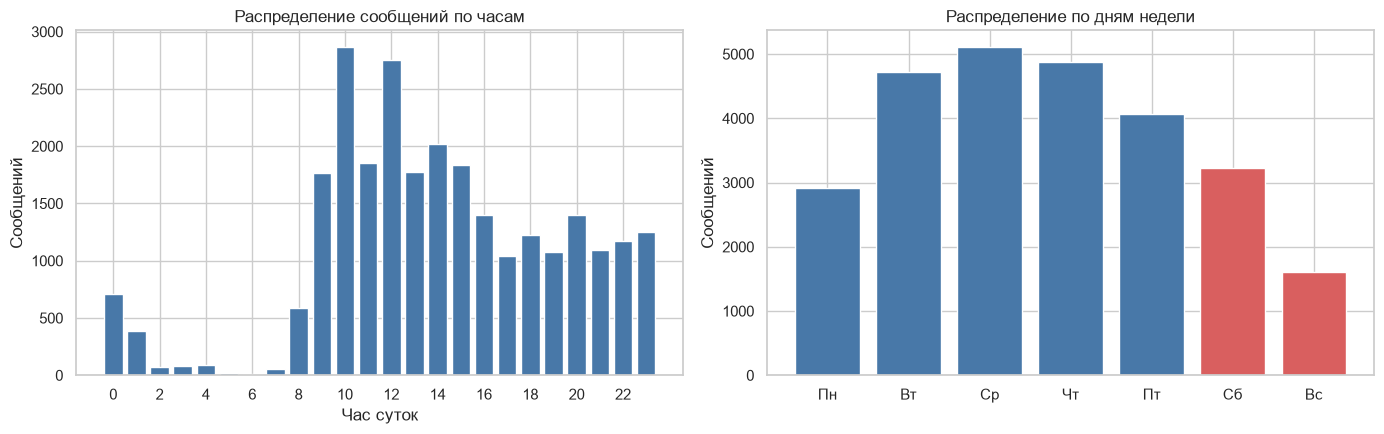

Пик активности: 10 часов, 2867 сообщений
Ночью (0–6 часов): 5.1%
В выходные: 18.2%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
by_hour = df.groupby('hour').size()
axes[0].bar(by_hour.index, by_hour.values, color='#4878a8')
axes[0].set_xlabel('Час суток')
axes[0].set_ylabel('Сообщений')
axes[0].set_title('Распределение сообщений по часам')
axes[0].set_xticks(range(0, 24, 2))

by_wd = df.groupby('weekday').size()
axes[1].bar([WEEKDAYS[i] for i in by_wd.index], by_wd.values,
            color=['#4878a8'] * 5 + ['#d95f5f'] * 2)
axes[1].set_ylabel('Сообщений')
axes[1].set_title('Распределение по дням недели')
fig.tight_layout()
save_fig('02_hour_weekday.png')
plt.show()

print('Пик активности:', int(by_hour.idxmax()), 'часов,', int(by_hour.max()), 'сообщений')
print('Ночью (0–6 часов):', f"{df['hour'].between(0, 5).mean():.1%}")
print('В выходные:', f"{(df['weekday'] >= 5).mean():.1%}")

**Рисунок 2 — Сообщения по часам и дням недели**

Чат живёт по учебному расписанию: пик в 10 часов утра (2867 сообщений), ночью с 0 до 6 часов пишется только 5,1 % сообщений, в выходные 18,2 %.

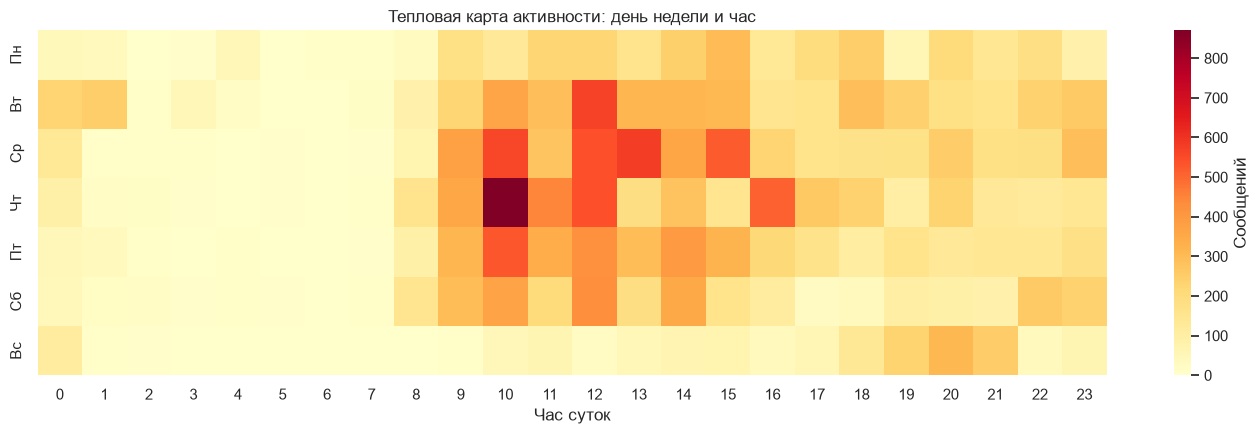

Самая активная клетка: Чт 10:00, 870 сообщений


In [8]:
pivot = df.pivot_table(index='weekday', columns='hour', values='length', aggfunc='size').fillna(0)
pivot.index = [WEEKDAYS[i] for i in pivot.index]

fig, ax = plt.subplots(figsize=(14, 4.5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Сообщений'})
ax.set_xlabel('Час суток')
ax.set_ylabel('')
ax.set_title('Тепловая карта активности: день недели и час')
fig.tight_layout()
save_fig('03_heatmap.png')
plt.show()

top_cell = pivot.stack().idxmax()
print('Самая активная клетка:', top_cell[0], f'{top_cell[1]}:00,', int(pivot.stack().max()), 'сообщений')

**Рисунок 3 — Тепловая карта активности по дням недели и часам**

Самая активная клетка четверг в 10 часов (870 сообщений), яркая полоса идёт по будним дням с 9 до 18 часов, то есть переписка привязана к парам.

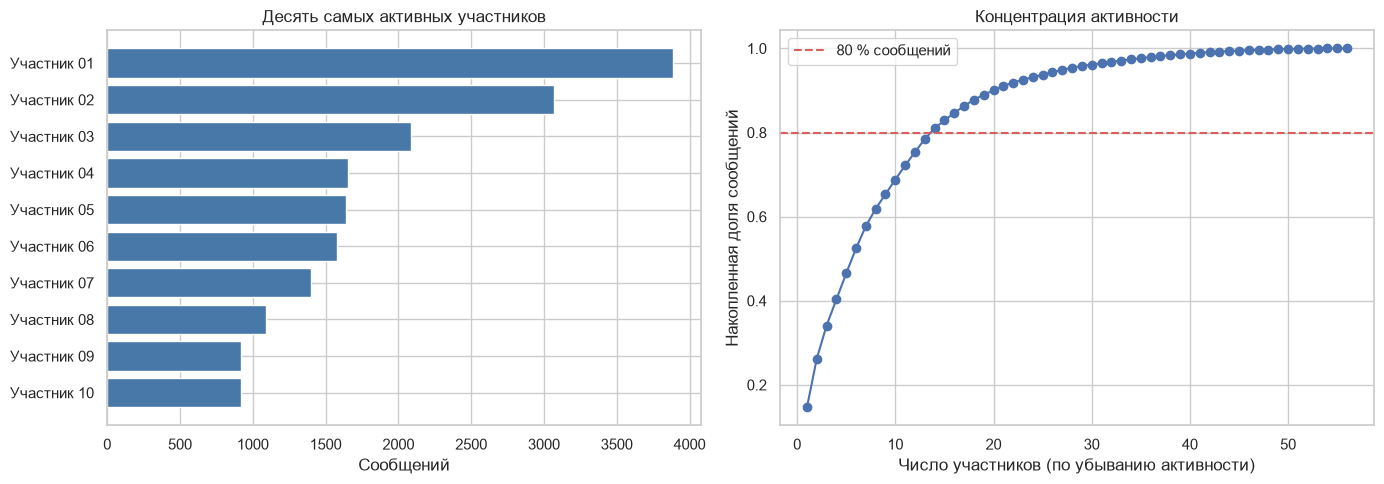

14 участников дают 80 % сообщений из 56
Доля самого активного: 14.7%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top10 = df['sender'].value_counts().head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color='#4878a8')
axes[0].set_xlabel('Сообщений')
axes[0].set_title('Десять самых активных участников')

share = df['sender'].value_counts(normalize=True).cumsum().reset_index(drop=True)
axes[1].plot(range(1, len(share) + 1), share.values, 'o-')
axes[1].axhline(0.8, color='#d95f5f', linestyle='--', label='80 % сообщений')
axes[1].set_xlabel('Число участников (по убыванию активности)')
axes[1].set_ylabel('Накопленная доля сообщений')
axes[1].set_title('Концентрация активности')
axes[1].legend()
fig.tight_layout()
save_fig('04_senders.png')
plt.show()

n80 = int((share < 0.8).sum() + 1)
print(f'{n80} участников дают 80 % сообщений из {df["sender"].nunique()}')
print('Доля самого активного:', f"{df['sender'].value_counts(normalize=True).iloc[0]:.1%}")

**Рисунок 4 — Активность участников**

Активность сильно сконцентрирована: 14 участников из 56 дают 80 % сообщений, на самого активного приходится 14,7 %.

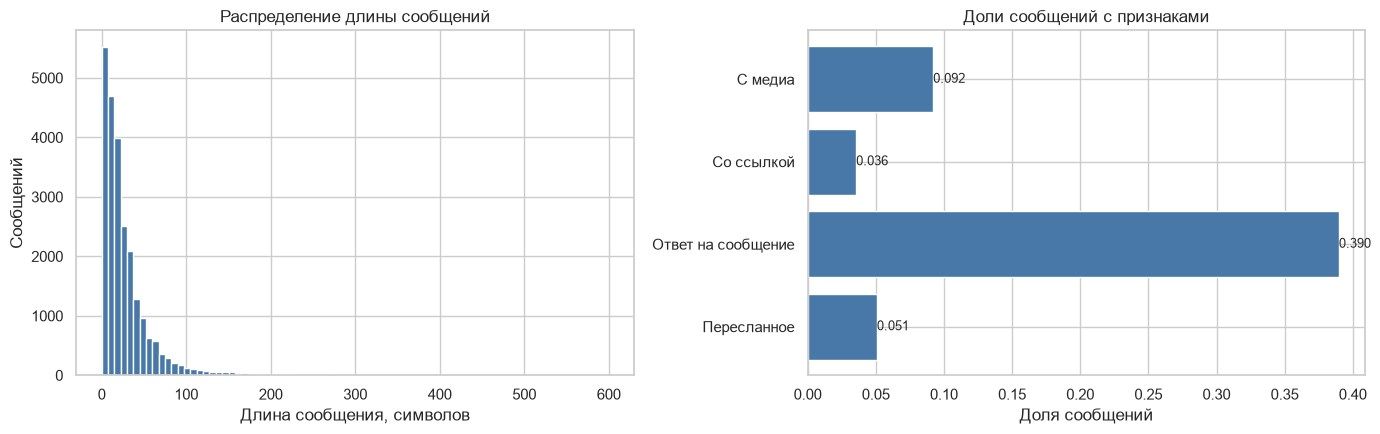

{'count': 26521.0, 'mean': 33.2, 'std': 102.6, 'min': 0.0, '25%': 6.0, '50%': 16.0, '75%': 33.0, 'max': 4081.0}
{'С медиа': '9.2%', 'Со ссылкой': '3.6%', 'Ответ на сообщение': '39.0%', 'Пересланное': '5.1%'}


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(df[df['length'] > 0]['length'], bins=80, range=(0, 600), color='#4878a8', edgecolor='white')
axes[0].set_xlabel('Длина сообщения, символов')
axes[0].set_ylabel('Сообщений')
axes[0].set_title('Распределение длины сообщений')

flags = pd.Series({
    'С медиа': df['has_media'].mean(),
    'Со ссылкой': df['has_link'].mean(),
    'Ответ на сообщение': df['is_reply'].mean(),
    'Пересланное': df['is_forward'].mean(),
})
bars = axes[1].barh(flags.index[::-1], flags.values[::-1], color='#4878a8')
axes[1].bar_label(bars, fmt='%.3f', fontsize=9)
axes[1].set_xlabel('Доля сообщений')
axes[1].set_title('Доли сообщений с признаками')
fig.tight_layout()
save_fig('05_length_flags.png')
plt.show()

print(df['length'].describe().round(1).to_dict())
print({k: f'{v:.1%}' for k, v in flags.items()})

**Рисунок 5 — Длина сообщений и доли признаков**

Сообщения короткие: медиана 16 символов, три четверти короче 33 символов, а самое длинное 4081; ответами на другие сообщения оказались 39,0 % сообщений, с медиа 9,2 %, со ссылкой 3,6 %.

## 4. Сохранение датасета

Сохраняю итоговый датасет в csv без текстов сообщений. Это и есть результат работы:
журнал активности, пригодный для анализа и обучения моделей.

In [11]:
columns = ['datetime', 'date', 'hour', 'weekday', 'weekday_name', 'chat', 'sender', 'sender_hash',
           'length', 'has_media', 'has_link', 'is_reply', 'is_forward', 'month']
dataset = df[columns].sort_values('datetime').reset_index(drop=True)
dataset.to_csv('data/messages.csv', index=False)

print('Строк:', len(dataset), '| столбцов:', dataset.shape[1])
print('Размер файла:', round(os.path.getsize('data/messages.csv') / 1024 / 1024, 2), 'МБ')
dataset.head()

Строк: 26521 | столбцов: 14
Размер файла: 2.83 МБ


,datetime,date,hour,weekday,weekday_name,chat,sender,sender_hash,length,has_media,has_link,is_reply,is_forward,month
0,2023-09-09 19:07:01,2023-09-09,19,5,Сб,231-329,Участник 02,631db03e,0,True,False,False,False,2023-09
1,2023-09-09 19:07:13,2023-09-09,19,5,Сб,231-329,Участник 02,631db03e,19,False,False,False,False,2023-09
2,2023-09-09 19:13:15,2023-09-09,19,5,Сб,231-329,Участник 07,38360e9c,1,False,False,False,False,2023-09
3,2023-09-09 19:13:53,2023-09-09,19,5,Сб,231-329,Участник 14,85d11236,39,False,False,True,False,2023-09
4,2023-09-09 19:14:12,2023-09-09,19,5,Сб,231-329,Участник 14,85d11236,18,False,False,False,False,2023-09


In [12]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 26521 entries, 0 to 26520
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datetime      26521 non-null  datetime64[us]
 1   date          26521 non-null  object        
 2   hour          26521 non-null  int32         
 3   weekday       26521 non-null  int32         
 4   weekday_name  26521 non-null  str           
 5   chat          26521 non-null  str           
 6   sender        26521 non-null  str           
 7   sender_hash   26521 non-null  str           
 8   length        26521 non-null  int64         
 9   has_media     26521 non-null  bool          
 10  has_link      26521 non-null  bool          
 11  is_reply      26521 non-null  bool          
 12  is_forward    26521 non-null  bool          
 13  month         26521 non-null  str           
dtypes: bool(4), datetime64[us](1), int32(2), int64(1), object(1), str(5)
memory usage: 1.9+ MB


## 5. Демонстрация пригодности датасета

Проверяю, что по собранным признакам вообще можно чему-то научиться. Задача: определить автора
сообщения по времени отправки и форме сообщения, без текста. Беру трёх самых активных участников
и обучаю случайный лес на признаках: час, день недели, длина, наличие медиа, ссылки, ответа,
пересылки, месяц.

Нижний уровень для сравнения: модель, всегда отвечающая самым частым классом.

In [13]:
top3 = dataset['sender'].value_counts().head(3).index.tolist()
sub = dataset[dataset['sender'].isin(top3)].copy()
print('Сообщений трёх участников:', len(sub))
print(sub['sender'].value_counts().to_dict())

features = ['hour', 'weekday', 'length', 'has_media', 'has_link', 'is_reply', 'is_forward']
X = sub[features].astype(float)
y = sub['sender']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                            random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

acc_dummy = accuracy_score(y_test, dummy.predict(X_test))
acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f'\nСамый частый класс: {acc_dummy:.4f}')
print(f'Случайный лес:      {acc_rf:.4f}')
print()
print(classification_report(y_test, rf.predict(X_test), digits=4))

Сообщений трёх участников: 9041
{'Участник 01': 3886, 'Участник 02': 3066, 'Участник 03': 2089}



Самый частый класс: 0.4299
Случайный лес:      0.5409

              precision    recall  f1-score   support

 Участник 01     0.5355    0.6975    0.6059       972
 Участник 02     0.5768    0.4993    0.5353       767
 Участник 03     0.4894    0.3103    0.3798       522

    accuracy                         0.5409      2261
   macro avg     0.5339    0.5024    0.5070      2261
weighted avg     0.5389    0.5409    0.5298      2261



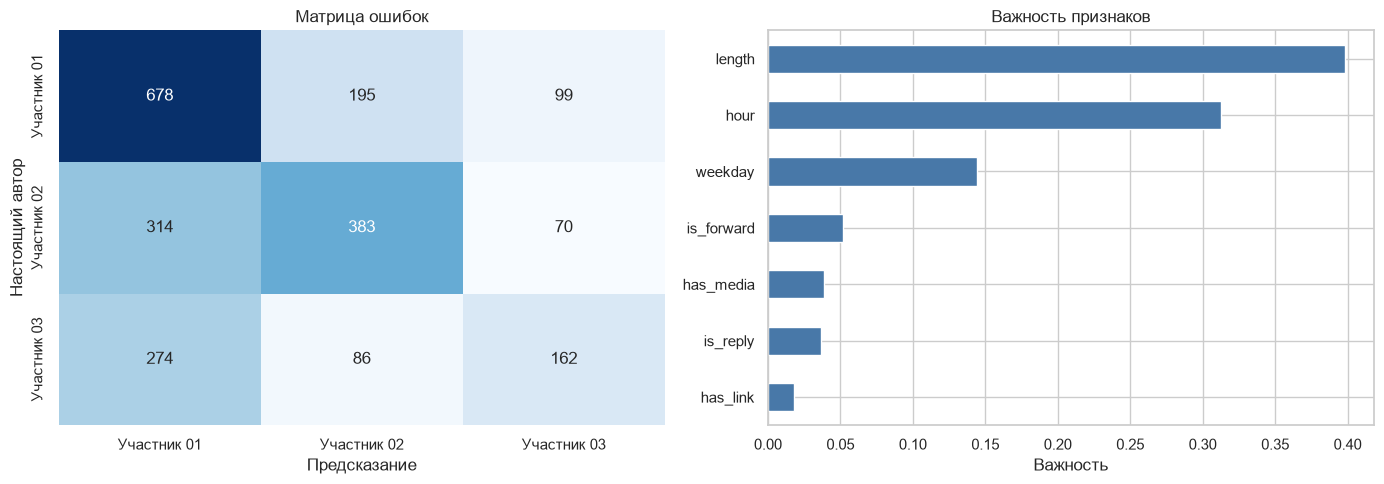

{'length': 0.398, 'hour': 0.313, 'weekday': 0.144, 'is_forward': 0.052, 'has_media': 0.039, 'is_reply': 0.036, 'has_link': 0.018}


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, rf.predict(X_test), labels=top3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=top3, yticklabels=top3, ax=axes[0])
axes[0].set_xlabel('Предсказание')
axes[0].set_ylabel('Настоящий автор')
axes[0].set_title('Матрица ошибок')

imp = pd.Series(rf.feature_importances_, index=features).sort_values()
imp.plot.barh(ax=axes[1], color='#4878a8')
axes[1].set_xlabel('Важность')
axes[1].set_title('Важность признаков')
fig.tight_layout()
save_fig('06_model.png')
plt.show()

print(imp.sort_values(ascending=False).round(3).to_dict())

**Рисунок 6 — Определение автора сообщения: матрица ошибок и важность признаков**

По времени и форме сообщения лес угадывает автора с точностью 0,5409 против 0,4299 у ответа «всегда самый активный», и сильнее всего опирается на длину сообщения (0,398) и час (0,313).

## 6. Выводы

1. **Сырые данные.** Экспорт чата группы 231-329 из Telegram: 26 895 записей за период
   с 9 сентября 2023 года по 20 августа 2026 года, из них 26 721 сообщение и 174 служебные записи.
   Структура неоднородная: у разных сообщений разный набор полей, текст бывает строкой
   и бывает списком кусков с разметкой.

2. **Датасет.** После разбора и очистки 26 521 сообщение, 14 столбцов: дата и время, час,
   день недели, чат, псевдоним отправителя, хеш отправителя, длина текста, признаки медиа, ссылки,
   ответа и пересылки, месяц. Удалено 200 записей: сообщения без отправителя и пустые без медиа.
   Файл `data/messages.csv` занимает 2,83 МБ, текстов и настоящих имён в нём нет.

3. **Что показал анализ.** Чат живёт по учебному расписанию: пик в 10 утра, самая активная
   клетка четверг в 10 часов, ночью 5,1 % сообщений, в выходные 18,2 %. По месяцам виден взрыв
   в сентябре 2023 года (5288 сообщений) и провалы летом. Активность концентрирована: 14 участников
   из 56 дают 80 % сообщений.

4. **Пригодность для обучения.** Случайный лес определяет одного из трёх самых активных авторов
   по времени и форме сообщения с точностью 0,5409 против 0,4299 у тривиальной модели.
   Результат скромный, и это ожидаемо: без текста у сообщений мало различий. Но прирост
   11 процентных пунктов показывает, что у участников разные привычки: длина сообщений (важность 0,398)
   и время активности (0,313) несут информацию об авторе.

5. **Сравнение с примером из материалов.** Пример `Анализ-активности` делает то же самое
   с журналом `watcher.csv`: время события, источник, категория, лента активности по дням.
   Здесь вместо приложений отправители, вместо категорий признаки сообщения, а тепловая карта
   по дням и часам заменяет ленту.

6. **Что можно добавить:** категории сообщений по тексту (вопрос, объявление, файл с заданием),
   связь активности с календарём сессий, граф ответов между участниками.